<a href="https://colab.research.google.com/github/CarlosM2002/MineriadeDatos/blob/main/Asignacion2_29551025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Asignación 2 - Análisis Exploratorio de Red Wine Quality Dataset
# Carlos Monsalve - CI:29551025
![Portada](https://drive.google.com/uc?export=download&id=1nJsrSG2YaGNGj-SYZq-QziuGpERzIsO_)


### 1. Descripción del dataset:


Cargamos el dataset y mostramos la cantidad de filas y columnas, que como podemos observar, existen 1599 registros y 12 variables en donde cada una de las variables son de tipo númerico, todas siendo de tipo flotante exceptuando por una que es de tipo entero.



In [ ]:
import pandas as pd
import numpy as np

url = f'https://drive.google.com/uc?export=download&id=18esTOTs5HIQzyLVTwdAbQQBBnhxRqyfu'
df = pd.read_csv(url)
print(df.shape)
print(df.dtypes)

(1599, 12)
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


### 2. Estadísticas descriptivas:

A continuación simplemente se presenta la tabla con media, mediana, desviación
estándar, mínimo y máximo para todas los variables de nuestro dataset las cuales no hay que filtrar ya que todas son numéricas.

In [ ]:
tabla_estadisticas = pd.DataFrame({
    'Media': df.mean(),
    'Mediana': df.median(),
    'Desv. Est.': df.std(),
    'Mín.': df.min(),
    'Máx.': df.max()
})

print(tabla_estadisticas)

                          Media   Mediana  Desv. Est.     Mín.       Máx.
fixed acidity          8.319637   7.90000    1.741096  4.60000   15.90000
volatile acidity       0.527821   0.52000    0.179060  0.12000    1.58000
citric acid            0.270976   0.26000    0.194801  0.00000    1.00000
residual sugar         2.538806   2.20000    1.409928  0.90000   15.50000
chlorides              0.087467   0.07900    0.047065  0.01200    0.61100
free sulfur dioxide   15.874922  14.00000   10.460157  1.00000   72.00000
total sulfur dioxide  46.467792  38.00000   32.895324  6.00000  289.00000
density                0.996747   0.99675    0.001887  0.99007    1.00369
pH                     3.311113   3.31000    0.154386  2.74000    4.01000
sulphates              0.658149   0.62000    0.169507  0.33000    2.00000
alcohol               10.422983  10.20000    1.065668  8.40000   14.90000
quality                5.636023   6.00000    0.807569  3.00000    8.00000


### 3. Valores faltantes:

Determinamos si hay valores nulos en nuestro dataset, lo cual rapidamente observamos que no es así, por ende, no hace falta realizar una limpieza de datos para evitar errores o perdida de precisión en los próximos gráficos.

In [ ]:
valores_nulos = df.isna().sum()

print(valores_nulos)

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


### 4. Histogramas:

Para los histogramas, se decidió trabajar con las variables de fixed acidity, volatile acidity y ph, para así formar un perfil de acidez del vino, en donde al observar estos gráficos, podemos comprender de forma más intuitiva la estructura química base del vino. Por un lado, la distribución de acidez fija muestra que la mayoría de vinos tienen una acidez fija moderada entre 6 y 8 g/dm³. Por otro lado, la distribución de acidez volatil indica que la concentración principal se encuentre los 0.3 y 0.7 g/dm³ y por último la distribución de ph cuya distribución en forma de campana, nos muestra que el pH esta balanceado en el valor central 3.2 y 3.4.

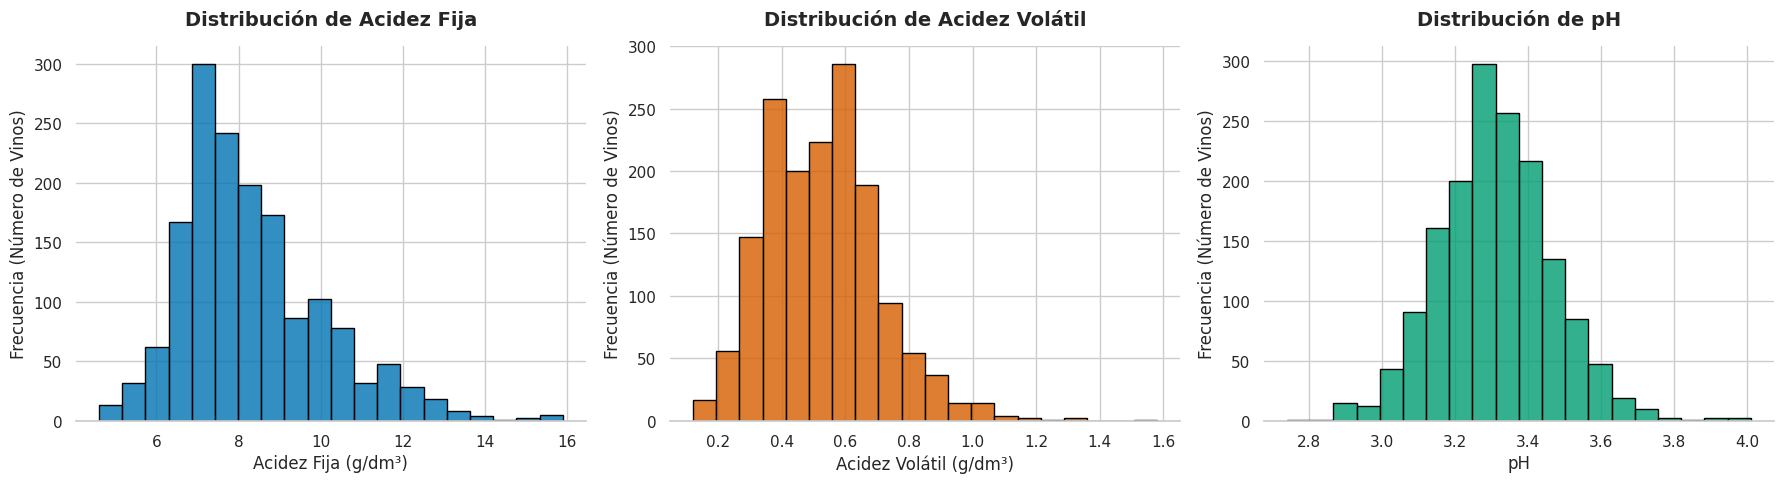

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = ['fixed acidity', 'volatile acidity', 'pH']
nombres_ejes = ['Acidez Fija (g/dm³)', 'Acidez Volátil (g/dm³)', 'pH']
titulos = ['Distribución de Acidez Fija', 'Distribución de Acidez Volátil', 'Distribución de pH']
colores = ['#0072B2', '#D55E00', '#009E73']

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(variables):
    ax = axes[i]
    sns.histplot(data=df, x=var, ax=ax, color=colores[i], bins=20, edgecolor='black', alpha=0.8)
    ax.set_title(titulos[i], fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(nombres_ejes[i], fontsize=12)
    ax.set_ylabel('Frecuencia (Número de Vinos)', fontsize=12)
    ax.set_ylim(bottom=0)
    sns.despine(ax=ax, left=True)

plt.tight_layout()
plt.show()


### 5. Box plots:

Para los Box plots, se decidió escoger las variable alcohol y cloruros, en donde para estos gráficos, podemos observar que las cajas representan el 50% central de los datos y la línea horizontal dentro de la caja es la mediana, es decir, el valor que se encuentra en el medio de todos los datos. Las otras líneas horizontales fuera de la caja, representan los limites normales esperados y los puntos rojos son los outliers, que son los datos que caen fuera de estos límites.

Como podemos observar, para la gráfica del alcohol hay 13 vinos que son más fuertes que la mayoría de los otros en donde superan el 13.5% de alcohol. En cambio para los cloruros, podemos observar que la caja es mucho más estrecha ya que la mayoría de los vinos tienen la misma cantidad de cloruros alrededor de 0.08 g/dm³, no obstante, hay más puntos rojos extendiéndose hacía arriba y hacía abajo indicando que hay más casos excepcionales de vinos que son más o incluso menos salados de lo habitual.

--- Alcohol (% vol.) ---
Límites normales esperados: [7.1000, 13.5000]
Cantidad de outliers detectados: 13

--- Cloruros (g/dm³) ---
Límites normales esperados: [0.0400, 0.1200]
Cantidad de outliers detectados: 112



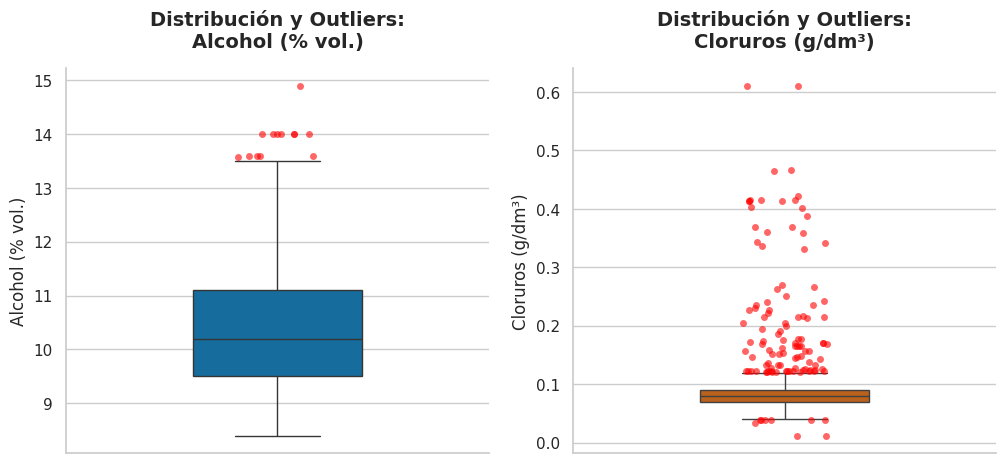

In [ ]:
variables = ['alcohol', 'chlorides']
nombres_ejes = ['Alcohol (% vol.)', 'Cloruros (g/dm³)']
colores = ['#0072B2', '#D55E00']
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, var in enumerate(variables):
    ax = axes[i]
    sns.boxplot(data=df, y=var, ax=ax, color=colores[i], width=0.4, showfliers=False)
    ax.set_title(f'Distribución y Outliers:\n{nombres_ejes[i]}', fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel(nombres_ejes[i], fontsize=12)
    sns.despine(ax=ax)

    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[var] < limite_inferior) | (df[var] > limite_superior)]

    print(f"--- {nombres_ejes[i]} ---")
    print(f"Límites normales esperados: [{limite_inferior:.4f}, {limite_superior:.4f}]")
    print(f"Cantidad de outliers detectados: {len(outliers)}\n")
    sns.stripplot(data=outliers, y=var, ax=ax, color="red", jitter=0.1, alpha=0.6, size=5)


### 6. Análisis de correlación

Se utilizó un mapa de calor para representar la correlación entre todas las variables del dataset, en donde se mapeó la escala de -1 a 1 para así visualizar el coeficiente de correlación, de forma tal que el color rojo representa una correlación positiva, el blanco puro indica la ausencia de correlación y el azul la correlación negativa. Gracias a este tipo de gráfico, de forma rápida podemos notar relaciones lógicas de la química de los vinos, por ejemplo la acidez fija tiene una correlación negativa con el pH y una fuerte correlación positiva con el ácido cítrico y la densidad.

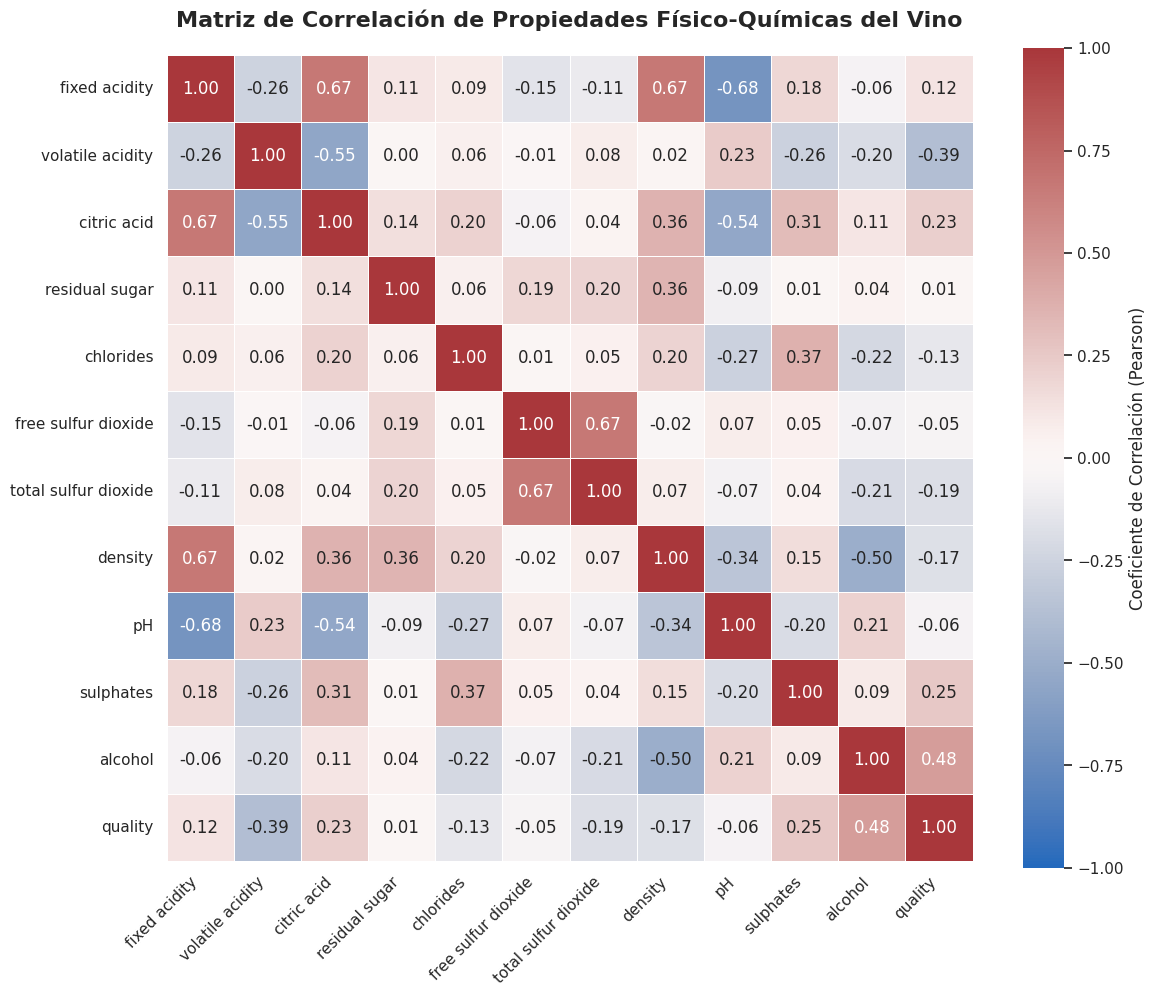

In [ ]:
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(
    corr,
    annot=True,
    cmap='vlag',
    fmt=".2f",
    vmin=-1, vmax=1,
    cbar_kws={'label': 'Coeficiente de Correlación'},
    square=True,
    linewidths=.5
)

plt.title('Matriz de Correlación de Propiedades del Vino', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Por último, se realizó un grafico Scatter Plot en donde se escogió las variables de total sulfur dioxide y free sulfur dioxide debido a su alto coeficiente de correlación y poder así observar como se comportan ambas variables en conjunto, observando con la linea naranja la tendencia general, la cual demuestra que mientras mayor cantidad de azufre libre, el vino siempre tendrá un mayor nivel de azufre total.

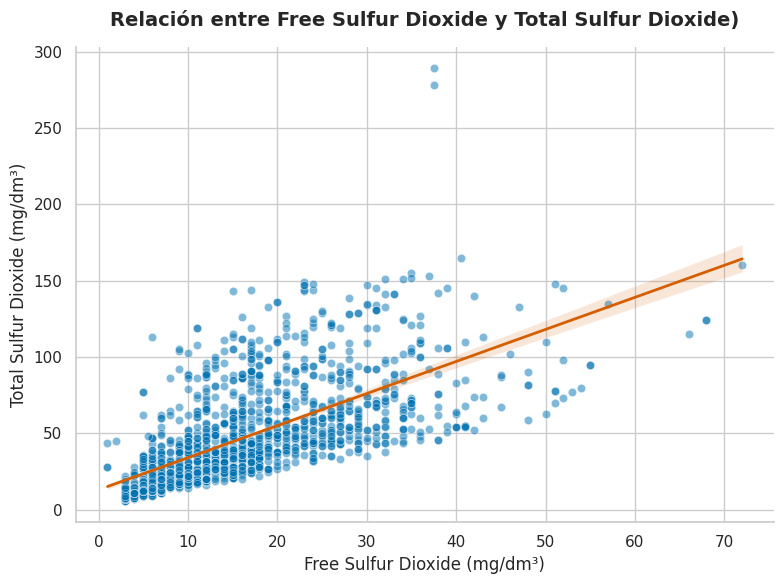

In [ ]:
var1 = 'free sulfur dioxide'
var2 = 'total sulfur dioxide'
correlacion_real = corr.loc[var1, var2]
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df,
    x=var1,
    y=var2,
    color='#0072B2',
    scatter_kws={'alpha': 0.5, 'edgecolors': 'w', 'linewidths': 0.5},
    line_kws={'color': '#D55E00', 'linewidth': 2}
)

plt.title(f'Relación entre {var1.title()} y {var2.title()})',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Free Sulfur Dioxide (mg/dm³)', fontsize=12)
plt.ylabel('Total Sulfur Dioxide (mg/dm³)', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()